In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict, Features, Sequence, ClassLabel, Value

#Загрузка данных

*   текст fashion тематики разбитый на токены
*   BIO-тэги сущностей (ITEM - наименование предмета одежды, FEAT - аттрибут/характеристика предмета, EVENT - событие/повод)


In [3]:
import json

with open('/content/drive/MyDrive/Colab Notebooks/dl/proj_fashion_ner/fashion_ner_synth(2).json', 'r', encoding='utf-8-sig') as f:
    data = json.load(f)

df = pd.DataFrame(data)[['tokens','ner_tags']]
df.head(5)

,tokens,ner_tags
0,"[Держа, наготове, блокнот, и, ручку, ,, вместе...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,"[Вы, можете, быть, слепы, к, тому, факту, ,, ч...","[O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT, B..."
2,"[Если, свитер, мешковат, в, хорошем, смысле, ,...","[O, B-ITEM, B-FEAT, O, O, O, O, O, O, O, O, B-..."
3,"[Если, вы, действительно, хотите, оставаться, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT..."
4,"[Срочная, новость, :, юбка-брюки, в, богемном,...","[O, O, O, B-ITEM, O, B-FEAT, O, O, O, O, O, O,..."


#EDA + FEATURE ENGINEERING

##EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tokens    974 non-null    object
 1   ner_tags  974 non-null    object
dtypes: object(2)
memory usage: 15.3+ KB


Датасет содержит 974 примера, нулевые значения отсутствуют

In [5]:
df.describe()

,tokens,ner_tags
count,974,974
unique,835,125
top,"[Что, носить, на, лето, ?, сделайте, сет, из, ...","[O, O, B-EVENT, I-EVENT, O, O, O]"
freq,8,90


##Удаление дубликатов

In [6]:
df = df.drop_duplicates(subset='tokens')
df.head(5)

,tokens,ner_tags
0,"[Держа, наготове, блокнот, и, ручку, ,, вместе...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
1,"[Вы, можете, быть, слепы, к, тому, факту, ,, ч...","[O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT, B..."
2,"[Если, свитер, мешковат, в, хорошем, смысле, ,...","[O, B-ITEM, B-FEAT, O, O, O, O, O, O, O, O, B-..."
3,"[Если, вы, действительно, хотите, оставаться, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT..."
4,"[Срочная, новость, :, юбка-брюки, в, богемном,...","[O, O, O, B-ITEM, O, B-FEAT, O, O, O, O, O, O,..."


In [ ]:
len(df)

835

после удаления дубликатов осталось 835 примеров

Типы тэгов в разметке

In [8]:
unique_tags = sorted({t for row in df["ner_tags"] for t in row})
unique_tags.remove("O")
unique_tags = ["O"] + unique_tags
unique_tags

['O', 'B-EVENT', 'B-FEAT', 'B-ITEM', 'I-EVENT', 'I-FEAT']

обогатим данные добавив признаки: количество токенов, длина сообщения и число тэгов для каджого типа

In [9]:
df = df.copy()

df.loc[:,'n_char'] = df['tokens'].apply(lambda tok: len(''.join(tok)))
df.loc[:,'n_tokens'] = df['tokens'].apply(lambda tok: len(tok))

for tag_name in unique_tags:
  df.loc[:,tag_name] = df['ner_tags'].apply(lambda tags: len([tag for tag in tags if tag_name in tag]))

df.head(5)

,tokens,ner_tags,n_char,n_tokens,O,B-EVENT,B-FEAT,B-ITEM,I-EVENT,I-FEAT
0,"[Держа, наготове, блокнот, и, ручку, ,, вместе...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",208,46,39,0,1,6,0,0
1,"[Вы, можете, быть, слепы, к, тому, факту, ,, ч...","[O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT, B...",145,32,29,0,1,2,0,0
2,"[Если, свитер, мешковат, в, хорошем, смысле, ,...","[O, B-ITEM, B-FEAT, O, O, O, O, O, O, O, O, B-...",118,24,14,1,3,4,1,1
3,"[Если, вы, действительно, хотите, оставаться, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT...",134,26,24,0,2,0,0,0
4,"[Срочная, новость, :, юбка-брюки, в, богемном,...","[O, O, O, B-ITEM, O, B-FEAT, O, O, O, O, O, O,...",243,51,44,1,2,3,1,0


In [10]:
df[['n_tokens', 'n_char']].agg(['mean','median','max', 'min', 'sum'])

,n_tokens,n_char
mean,9.743713,45.535329
median,8.000000,36.000000
max,71.000000,364.000000
min,3.000000,16.000000
sum,8136.000000,38022.000000


медианный размер сообщения - 8 токенов

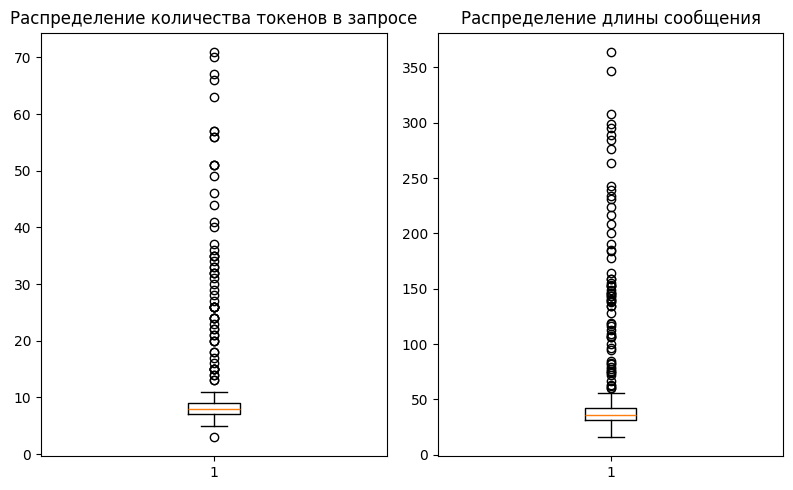

In [ ]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Распределение количества токенов в запросе')
plt.boxplot(df['n_tokens'])
plt.subplot(1,2,2)
plt.title('Распределение длины сообщения')
plt.boxplot(df['n_char'])
plt.tight_layout();

In [ ]:
tag_ratio = df[unique_tags].sum() / df[unique_tags].sum().sum()
tag_ratio

,0
O,0.709808
B-EVENT,0.031219
B-FEAT,0.124508
B-ITEM,0.096853
I-EVENT,0.031219
I-FEAT,0.006391


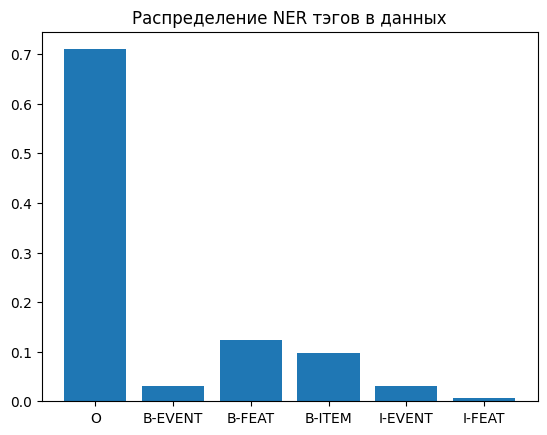

In [ ]:
plt.bar(tag_ratio.index, tag_ratio)
plt.title('Распределение NER тэгов в данных');

##Объединение классов

Ввиду преимущественно односложности характеристик вещей и событий, объеденим классы B и I тэгов

In [ ]:
#корректирует разметку для связок "на работу", "для свадьбы" и объединяем B и I тэги
def tag_modifying(tags):
  for i in range(len(tags)):
    if i == len(tags)-1:
      continue
    if tags[i] == 'B-EVENT' and tags[i+1] == 'I-EVENT' :
      tags[i] = 'O'
      tags[i+1] = 'B-EVENT'
    if tags[i] == 'I-EVENT':
      tags[i] = 'B-EVENT'
    if tags[i] == 'I-FEAT':
      tags[i] = 'B-FEAT'

df['ner_tags'].apply(tag_modifying);

In [ ]:
unique_tags = sorted({t for row in df["ner_tags"] for t in row})
unique_tags.remove("O")
unique_tags = ["O"] + unique_tags
unique_tags

['O', 'B-EVENT', 'B-FEAT', 'B-ITEM']

In [ ]:
del df['I-EVENT'], df['I-FEAT']

for tag_name in unique_tags:
  df.loc[:,tag_name] = df['ner_tags'].apply(lambda tags: len([tag for tag in tags if tag_name in tag]))

df.head(5)

,tokens,ner_tags,n_char,n_tokens,O,B-EVENT,B-FEAT,B-ITEM
0,"[Держа, наготове, блокнот, и, ручку, ,, вместе...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",208,46,39,0,1,6
1,"[Вы, можете, быть, слепы, к, тому, факту, ,, ч...","[O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT, B...",145,32,29,0,1,2
2,"[Если, свитер, мешковат, в, хорошем, смысле, ,...","[O, B-ITEM, B-FEAT, O, O, O, O, O, O, O, O, O,...",118,24,15,1,4,4
3,"[Если, вы, действительно, хотите, оставаться, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT...",134,26,24,0,2,0
4,"[Срочная, новость, :, юбка-брюки, в, богемном,...","[O, O, O, B-ITEM, O, B-FEAT, O, O, O, O, O, O,...",243,51,44,2,2,3


In [ ]:
tag_ratio = df[unique_tags].sum() / df[unique_tags].sum().sum()
tag_ratio

,0
O,0.740905
B-EVENT,0.031342
B-FEAT,0.130900
B-ITEM,0.096853


/tmp/ipython-input-2647218962.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(tag_ratio.index[i], tag_ratio[i], df[unique_tags].sum().iloc[i], ha='center')
/tmp/ipython-input-2647218962.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(tag_ratio.index[i], tag_ratio[i], df[unique_tags].sum().iloc[i], ha='center')
/tmp/ipython-input-2647218962.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(tag_rat

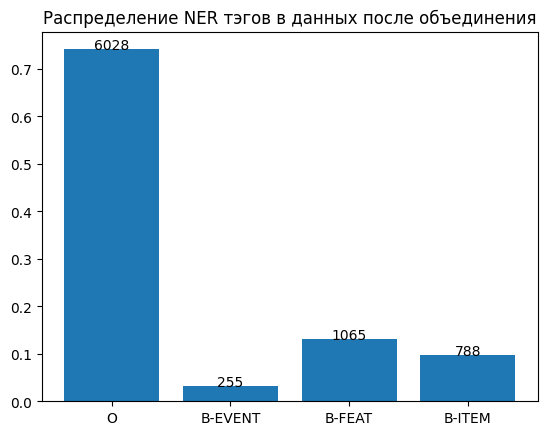

In [ ]:
plt.bar(tag_ratio.index, tag_ratio)

for i in range(len(tag_ratio)):
  plt.text(tag_ratio.index[i], tag_ratio[i], df[unique_tags].sum().iloc[i], ha='center')
plt.title('Распределение NER тэгов в данных после объединения');

Таким образом получаем распределение классов:

*   О - 6028 тэгов (74%)
*   B-EVENT - 255 тэгов (3%)
*   B-FEAT - 1065 тэгов (13%)
*   B-ITEM - 788 тэгов (1%)



In [ ]:
label2id = {lbl: i for i, lbl in enumerate(unique_tags)}
id2label = {i: lbl for lbl, i in label2id.items()}
id2label

{0: 'O', 1: 'B-EVENT', 2: 'B-FEAT', 3: 'B-ITEM'}

Для компенсации дисбаланса классов сопоставим каждому классу вес

In [ ]:
tag_weight = [1 - ratio for ratio in tag_ratio]
tag_weight

[0.2590953785644051,
 0.9686578171091446,
 0.8691002949852508,
 0.9031465093411997]

##Кодирование тэгов

In [ ]:
df["tags"] = df["ner_tags"].apply(lambda row: [label2id[t] for t in row])
df.head(5)

,tokens,ner_tags,n_char,n_tokens,O,B-EVENT,B-FEAT,B-ITEM,tags
0,"[Держа, наготове, блокнот, и, ручку, ,, вместе...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",208,46,39,0,1,6,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[Вы, можете, быть, слепы, к, тому, факту, ,, ч...","[O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT, B...",145,32,29,0,1,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 0, ..."
2,"[Если, свитер, мешковат, в, хорошем, смысле, ,...","[O, B-ITEM, B-FEAT, O, O, O, O, O, O, O, O, O,...",118,24,15,1,4,4,"[0, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, ..."
3,"[Если, вы, действительно, хотите, оставаться, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-FEAT...",134,26,24,0,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, ..."
4,"[Срочная, новость, :, юбка-брюки, в, богемном,...","[O, O, O, B-ITEM, O, B-FEAT, O, O, O, O, O, O,...",243,51,44,2,2,3,"[0, 0, 0, 3, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


#Сборка и сохранение датасета

In [ ]:
features = Features({
    "tokens": Sequence(Value("string")),
    "tags": Sequence(ClassLabel(num_classes=len(unique_tags), names=unique_tags))
})

hf_all = Dataset.from_pandas(df[['tokens','tags']], features=features, preserve_index=False)
ds = hf_all.train_test_split(test_size=0.2, seed=1)
ds

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 668
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 167
    })
})

In [ ]:
# вхождение классов в тестовый датасет
from collections import Counter

cnt = Counter()
full = []
for row in ds['test']:
  full += row['tags']
cnt.update(full)

cnt

Counter({0: 1065, 2: 225, 3: 145, 1: 52})

In [ ]:
save_dir = '/content/drive/MyDrive/Colab Notebooks/dl/proj_fashion_ner/fashion_dataset_dict'
ds.save_to_disk(save_dir)

with open(f"{save_dir}/label_maps.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label, "tag_weight": tag_weight}, f, ensure_ascii=False, indent=2)

Saving the dataset (0/1 shards):   0%|          | 0/668 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/167 [00:00<?, ? examples/s]